# Computational Machine Learning: Assignment 2 - Jonas Inocencio S3787701

# 1. Setup

**Imports**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
)

In [2]:
from typing import cast # To remove Pycharm errors on Windows

train_full = cast(pd.DataFrame, pd.read_csv('wildfire_cls_train_full.csv'))
unknown_full = cast(pd.DataFrame, pd.read_csv('wildfire_cls_test_features.csv'))

train_full.head(100)
# unknown_data.head(10)

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,fire_type,satellite,instrument,brightness_k,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct,fire_intensity
0,-22.1967,-61.5275,2024-08-12,1838,2024,NaN,Winter,D,South_America,Peru,Deforestation,Suomi-NPP,VIIRS,360.26,nominal,40.6,39.0,0.11,17.1,Extreme
1,64.2205,-53.4116,2024-07-11,424,2024,7.0,Summer,N,North_America,Canada,Forest,Suomi-NPP,VIIRS,326.20,high,38.9,NaN,0.06,13.2,Low
2,38.6810,9.5739,2024-06-18,546,2024,6.0,Summer,N,Mediterranean,Spain,Wildfire,AQUA,MODIS,343.36,high,36.9,30.1,0.19,35.2,High
3,68.1959,-90.3475,2024-08-26,2240,2024,8.0,Summer,N,North_America,USA,Forest,TERRA,MODIS,389.16,nominal,43.8,17.7,0.98,32.8,Extreme
4,0.6527,118.6227,2025-08-09,2301,2025,8.0,Summer,N,Southeast_Asia,Malaysia,Peatland,TERRA,MODIS,335.68,high,34.8,1.0,0.18,83.2,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,-19.2171,6.5621,2025-10-26,555,2025,10.0,Spring,N,Sub_Saharan_Africa,Angola,Savanna,NOAA-20,VIIRS,340.22,high,30.5,24.8,0.14,22.0,High
96,2.3414,118.2680,2025-02-05,1039,2025,2.0,Winter,D,Southeast_Asia,Philippines,Peatland,TERRA,MODIS,347.40,high,25.6,6.9,2.31,43.8,High
97,65.7722,-113.6341,2025-07-18,743,2025,7.0,Summer,D,North_America,USA,Prescribed,NOAA-20,VIIRS,340.50,high,41.8,0.1,4.51,7.9,High
98,36.2838,-71.7574,2024-09-11,1718,2024,9.0,Autumn,D,North_America,Canada,Forest,AQUA,MODIS,NaN,high,36.1,23.6,0.24,10.7,Moderate


In [3]:
train_full.shape

(4340, 20)

In [4]:
train_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        4340 non-null   float64
 1   longitude       4340 non-null   float64
 2   acq_date        4340 non-null   str    
 3   acq_time        4340 non-null   int64  
 4   year            4340 non-null   int64  
 5   month           3924 non-null   float64
 6   season          4340 non-null   str    
 7   daynight        4340 non-null   str    
 8   region          4340 non-null   str    
 9   country         4340 non-null   str    
 10  fire_type       4340 non-null   str    
 11  satellite       4340 non-null   str    
 12  instrument      4340 non-null   str    
 13  brightness_k    4013 non-null   float64
 14  confidence      4340 non-null   str    
 15  temp_max_c      4340 non-null   float64
 16  wind_max_kmh    4133 non-null   float64
 17  precip_mm       4340 non-null   float64
 18 

In [5]:
train_full.describe()

,latitude,longitude,acq_time,year,month,brightness_k,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,4340.000000,4340.000000,4340.000000,4340.000000,3924.000000,4013.000000,4340.000000,4133.000000,4340.000000,4340.000000
mean,9.821703,29.430626,1177.046774,2024.501843,7.240316,336.677742,35.082627,17.508033,2.597111,37.924378
std,24.321271,78.842700,683.844117,0.500054,2.791615,18.539217,5.821218,17.051980,3.062512,18.731153
min,-42.988300,-167.990600,0.000000,2024.000000,1.000000,290.000000,17.700000,0.000000,0.000000,5.000000
25%,-8.611625,-40.980600,602.000000,2024.000000,5.000000,324.860000,31.000000,5.100000,0.600000,24.200000
50%,10.268500,34.833700,1208.000000,2025.000000,8.000000,335.530000,35.100000,12.400000,1.540000,36.200000
75%,29.011025,95.166775,1752.000000,2025.000000,9.000000,346.990000,39.125000,24.000000,3.370000,50.500000
max,69.930900,153.754900,2359.000000,2025.000000,12.000000,503.710000,54.100000,130.700000,23.690000,95.000000


**Notes**
- 3 features with missing values: month, brightness_k, wind_max_kmh

# 2. Exploratory Data Analysis (EDA)

## 2.0. Basic Distribution

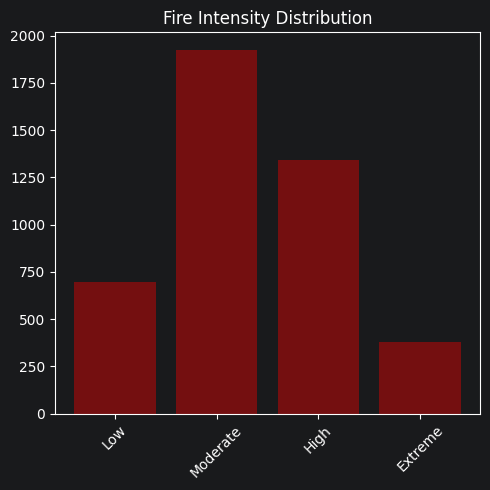

fire_intensity
Low          698
Moderate    1921
High        1340
Extreme      381
Name: count, dtype: int64


In [6]:
intensity_order = ['Low', 'Moderate', 'High', 'Extreme']
counts = train_full['fire_intensity'].value_counts().reindex(intensity_order)

plt.figure(figsize=(5,5))
plt.bar(counts.index, counts.values, alpha=0.4, color='r')
plt.title("Fire Intensity Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(train_full['fire_intensity'].value_counts().reindex(['Low', 'Moderate', 'High', 'Extreme']))

**Notes**
- Imbalanced distribution

In [7]:
train_full.isna().sum()
# unknown_data.isna().sum()

latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month             416
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64

**Notes**
- Testing data has no missing values, only training data
- month: 416 missing values
- brightness_k: 327 missing values
- wind_max_kmh: 207 missing values
- month has missing values, but acq_date has none. month can be obtained from acq_date


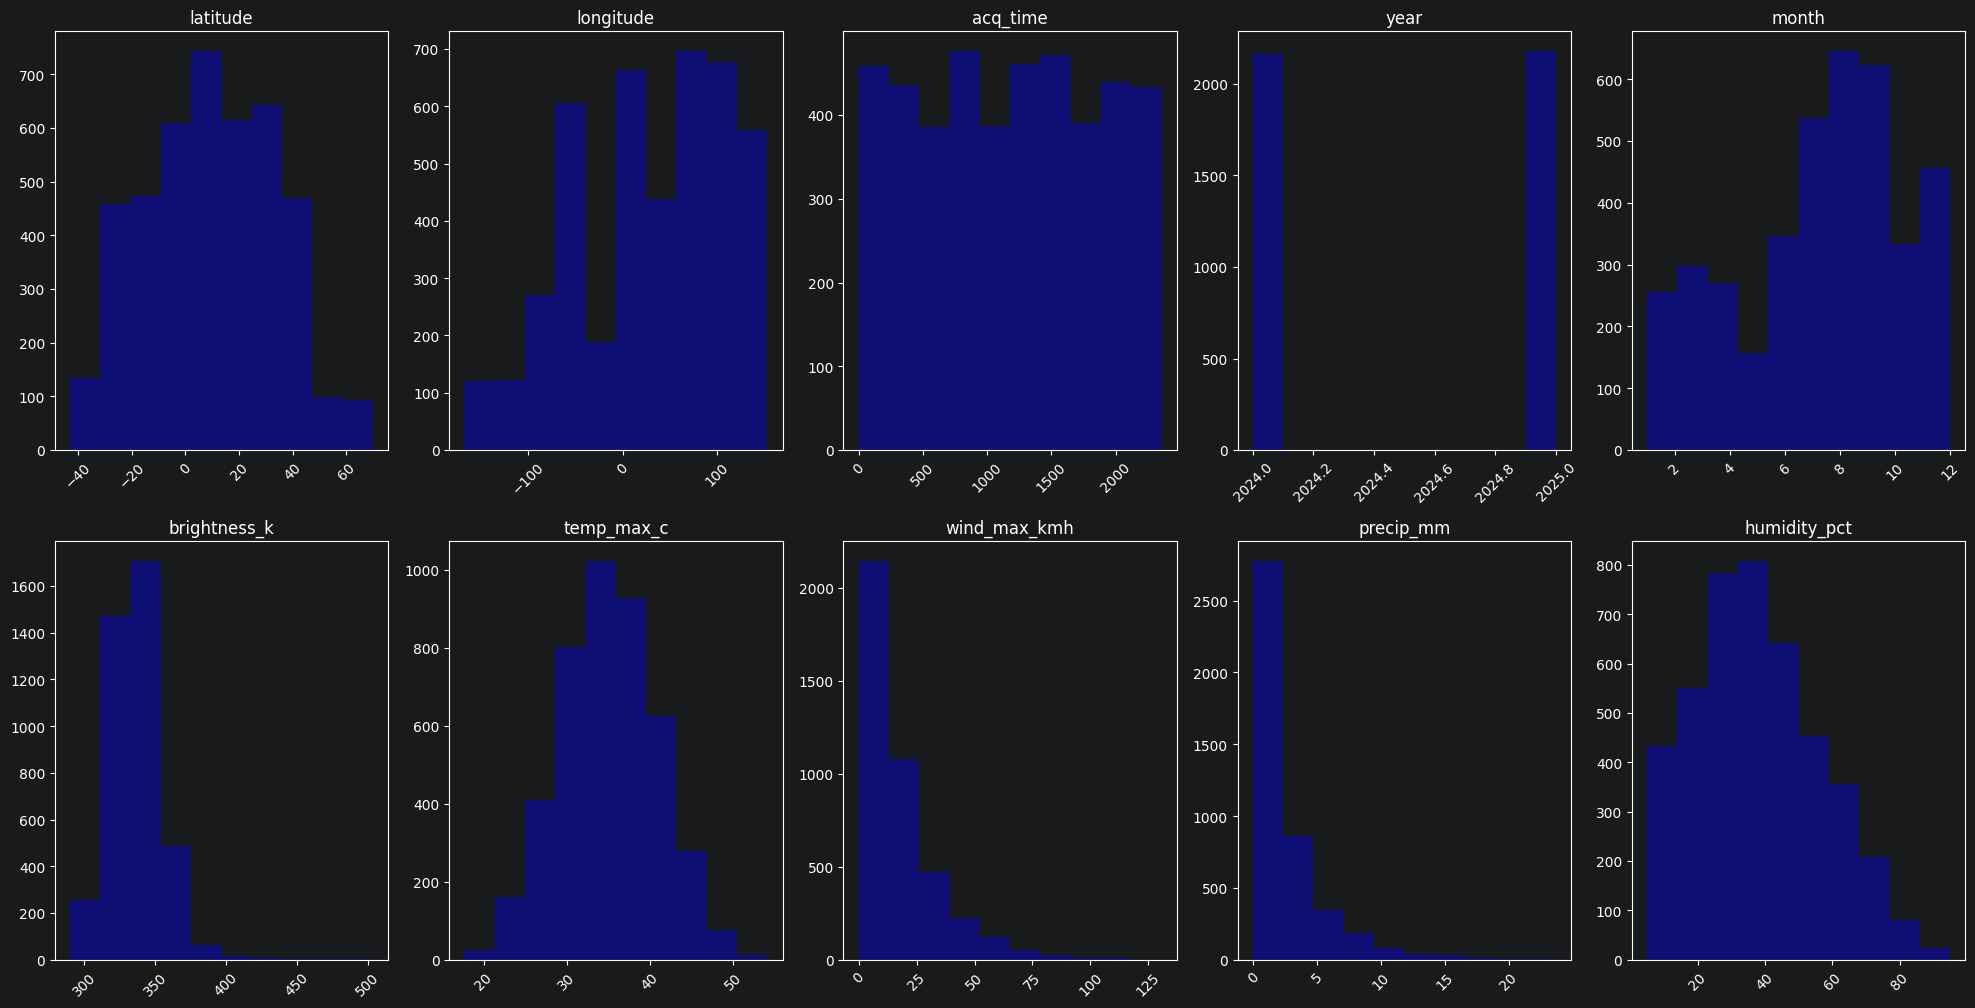

In [8]:
# Numeric Feature Distribution

plt.figure(figsize=(20,20))
for i, col in enumerate(train_full.select_dtypes(include='number').columns):
    plt.subplot(4,5,i+1)
    plt.hist(train_full[col], alpha=0.4, color='b', density=False)
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Notes**
- Latitude grouped around 10 (closer to the equator)
- Longitude harder to discern, since the horizontal plane is less of an indicator of country heat
- month: generally grouped around july-september (Northern Hemisphere Summer) with a smaller bump in December (SH Summer)
- brightness_k: Grouped around ~350. Outliers up to ~500
- max wind / precipitation: SIGNIFICANTLY more records with low values. Seems to be a major indicator
- max temp: avg \~35c. 40+ days are rare in most countries (\~60c is the max recorded globally). Very few sub 25c records
- humidity: spike at ~40%
- acq. time and year have balanced graphs. Not too much to discern from here
- Heavy right-skewedness in precipitation
- Brightness may have some outliers (visually, maximum values at ~400, but graph expands past 500)

In [9]:
# It seems like there is some heavy correlation between satellite type and scanning instrument type

train_full.groupby('satellite')['instrument'].nunique()
# unknown_data.groupby('satellite')['instrument'].nunique()

satellite
AQUA         1
NOAA-20      1
Suomi-NPP    1
TERRA        1
Name: instrument, dtype: int64

**Notes**
- Each satellite has one single instrument type. Total correlation.
- AQUA and TERRA use MODIS
- Suomi-NPP and NOAA-20 use VIIRS
- The same is true for the test data
- The instrument column is therefore just noise. It doesn't provide any meaningful data, and can be safely dropped

In [10]:
# Check unique values and counts


# train_data['month'].value_counts()
# train_data['season'].value_counts()
# train_data['daynight'].value_counts()
train_full['region'].value_counts()
# train_data['country'].value_counts()
# train_data['fire_type'].value_counts()
# train_data['satellite'].value_counts()
# train_data['instrument'].value_counts()
# train_data['brightness_k'].value_counts()
# train_data['confidence'].value_counts()
# train_data['temp_max_c'].value_counts()
# train_data['wind_max_kmh'].value_counts()
# train_data['precip_mm'].value_counts()
# train_data['humidity_pct'].value_counts()
# train_data['fire_intensity'].value_counts()

region
South_Asia            895
South_America         771
Southeast_Asia        761
Sub_Saharan_Africa    715
Mediterranean         497
North_America         426
Australia             275
Name: count, dtype: int64

**Notes**
- Season: Spring (1333) > Summer (1315) > Winter (915) > Autumn (777). Does not consider intensity
- Day Night: Relatively even spread, favouring day (2392 vs 1948)
- Regions: South Asia (986) > South America (771) > Southeast Asia (761) > SubSaharan Africa (715) > Mediterranean (497) > North America (426) > Australia (275)
- Country: Australia (275) > Sri Lanka (202) > India (187) ... Australia makes sense because off the size of the country and relative dryness/heat
- Fire Type: Agriculture (1050) and Forest (714) significantly higher than the others. Bushfire (82) has the fewest occurrences
- Confidence: Very few low confidence entries (406). Could potentially reduce weight
- No East/West Europe, or East Asia

## 2.1. Feature-Feature Correlation

**Preface**
- To examine feature correlation, categorical features would need to be encoded to numerical
- One-Hot Encoding can be used for unordered categorical features (region, country, fire_type, satellite, instrument, season, daynight)
- There are A LOT of countries. While manageable for the computer, physical analysis would be much more tricky with so many more features. Just looking at the region may be sufficient

In [11]:
# Copy of dataframe to safely modify for correlation analysis
corr_df = train_full.copy()

# Handle missing data

# Change acq_date to datetime format
corr_df['acq_date'] = pd.to_datetime(corr_df['acq_date'], format='%Y-%m-%d')

# ADD MONTH FROM DATE WHERE IT'S MISSING
corr_df['month'] = corr_df['month'].fillna(corr_df['acq_date'].dt.month)

# Brightness and Wind Speed options: Remove, Use median values, create regression model
# Remove for now
print(f"{corr_df.isna().sum()} missing values")
print(corr_df.shape)

corr_df.dropna(inplace=True)

print(f"{corr_df.isna().sum()} missing values")
print(corr_df.shape)

latitude            0
longitude           0
acq_date            0
acq_time            0
year                0
month               0
season              0
daynight            0
region              0
country             0
fire_type           0
satellite           0
instrument          0
brightness_k      327
confidence          0
temp_max_c          0
wind_max_kmh      207
precip_mm           0
humidity_pct        0
fire_intensity      0
dtype: int64 missing values
(4340, 20)
latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
fire_intensity    0
dtype: int64 missing values
(3831, 20)


In [12]:
# Drop country and instrument
corr_df = corr_df.drop(columns=['country'])
corr_df = corr_df.drop(columns=['instrument'])

# Ordinal Encoding
confidence_order = {'low': 0, 'nominal': 1, 'high': 2}
intensity_order = {'Low': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3}

corr_df['confidence'] = corr_df['confidence'].map(confidence_order)
corr_df['fire_intensity'] = corr_df['fire_intensity'].map(intensity_order)

# One Hot Encoding
from sklearn.preprocessing import OneHotEncoder

# perform one hot encoding on city and nominal type columns
ohc = OneHotEncoder(handle_unknown='ignore')
ohc.fit(corr_df[['region', 'fire_type', 'satellite', 'season', 'daynight']])

enc = ohc.transform(corr_df[['region', 'fire_type', 'satellite', 'season', 'daynight']]).toarray()

# Add these new binary values to the data frame, and drop the originals
enc_cols = ohc.get_feature_names_out(['region', 'fire_type', 'satellite', 'season', 'daynight'])
enc_df = pd.DataFrame(enc, columns=enc_cols, index=corr_df.index)
corr_df = pd.concat([corr_df.drop(columns=['region', 'fire_type', 'satellite', 'season', 'daynight']), enc_df], axis=1)

print(enc.shape, ohc.categories)

(3831, 27) auto


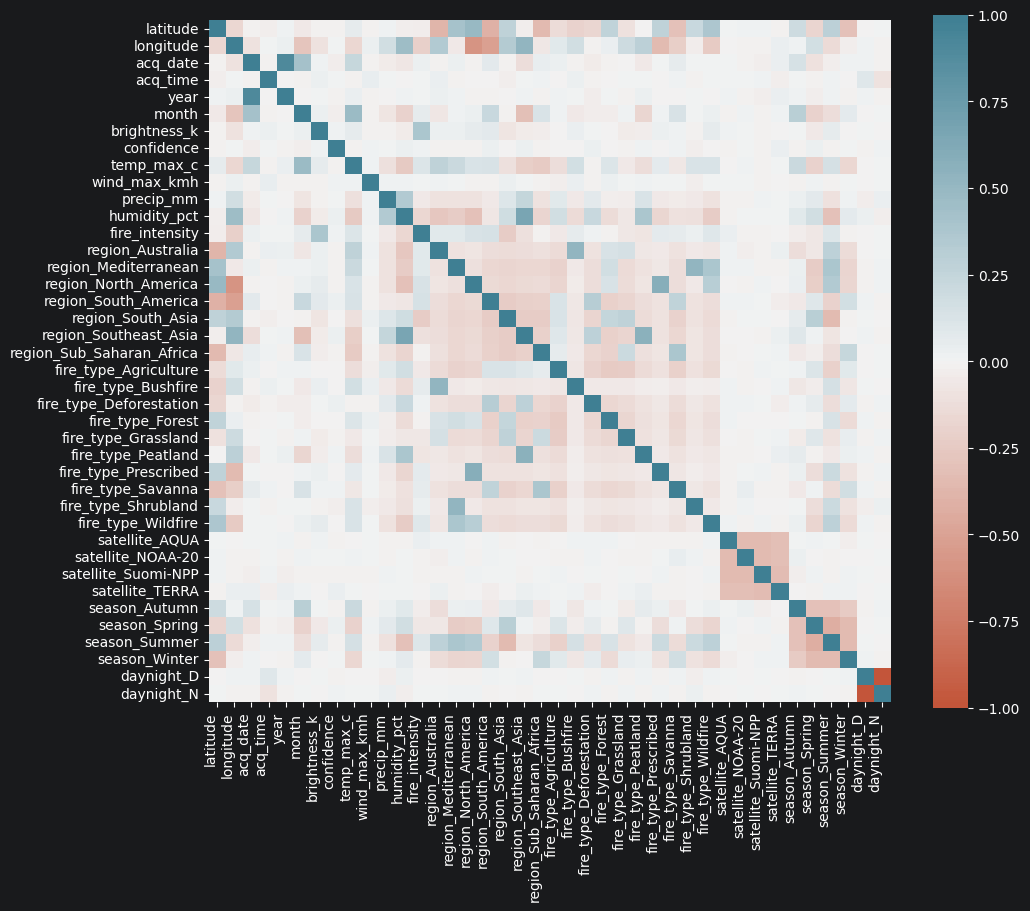

In [13]:
f, ax = plt.subplots(figsize=(11, 9))
corr = corr_df.corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);

**Notes**
- Several clusters of categorical data. Not informative
- Region / Fire type correlation shows common types in a region
- Wildfires have the highest positive intensity correlation of the fire types. Peat have the weakest
- Summer has the highest positive intensity correlation of the seasons.

# 3. Pre-Processing

## 3.1. Feature Engineering

In [14]:
# Remove overlapping data from temporal features (acq_date, month, etc.). Convert to specific features (year, month, day, hour)
def organise_temporal(df):
    df = df.copy()
    # drop the minutes from acq_time. Hour should be sufficient and helps organise temporal features
    df['acq_date'] = pd.to_datetime(df['acq_date'])
    df['month'] = df['acq_date'].dt.month
    df['day_of_year'] = df['acq_date'].dt.dayofyear
    df['hour'] = df['acq_time'] // 100

    # drop unnecessary columns
    df = df.drop(columns=['acq_time', 'acq_date'])

    return df

# Fill all missing values of a column with the median of every entry matching its value of another feature
def fillna_by_group(df, lookups, group_col, fallbacks):
    # Fills all missing values in a column with the values in the lookup table, grouped by the provided group name
    df = df.copy()
    for col, lookup in lookups.items():
        filled =  df[group_col].map(lookup).fillna(fallbacks[col])
        df[col] = df[col].fillna(filled)
    return df

## 3.2. Train/Validation Split

In [15]:
# Pre-split: deterministic data changes
train_data = train_full.copy()
unk_data = unknown_full.copy()

# Map ordinals to integer scale
intensity_order  = {'Low': 0, 'Moderate': 1, 'High': 2, 'Extreme': 3}
confidence_order = {'low': 0, 'nominal': 1, 'high': 2}

train_data['fire_intensity'] = train_data['fire_intensity'].map(intensity_order)
train_data['confidence'] = train_data['confidence'].map(confidence_order)
unk_data['confidence'] = unk_data['confidence'].map(confidence_order)

# Drop instrument - complete correlation with satellite
train_data = train_data.drop(columns=['instrument'])
unk_data = (unk_data.drop(columns=['instrument']))

# Re-organise temporal data
train_data = organise_temporal(train_data)
unk_data = organise_temporal(unk_data)

# Duplicate training data for hold-out validation to be used for the neural network pipeline
train_data_nn = train_data.copy()

**Notes**
- Since the fire_intensity and confidence changes are deterministic, they can be modified without risk of data leakage; nothing is being learnt from training data
- The instrument column can safely be removed due to its perfect correlation with satellite
- Countries have not been removed. Though keeping them adds a lot of additional data (especially after they are encoded), they have the potential to provide very meaningful inter-regional data

In [16]:
# 5-fold Cross Validation Splitting
from sklearn.model_selection import StratifiedKFold, cross_validate

# 80/20 Train/Test split. Test data is not touched until final evaluation
train_data, test_data = train_test_split(train_data, test_size=0.2, stratify=train_data['fire_intensity'], random_state=0)

# 60/20/20 train/val/test split for neural networks. Cross validation is extremely expensive with neural networks
train_data_nn, test_data_nn = train_test_split(train_data_nn, test_size=0.2, stratify=train_data_nn['fire_intensity'], random_state=0)
train_data_nn, val_data_nn = train_test_split(train_data_nn, test_size=0.25, stratify=train_data_nn['fire_intensity'], random_state=0)


# Split target from data
train_x = train_data.copy().drop(columns=['fire_intensity'])
train_y = train_data['fire_intensity']

test_x = test_data.copy().drop(columns=['fire_intensity'])
test_y = test_data['fire_intensity']

# repeat on nn set
train_x_nn = train_data_nn.copy().drop(columns=['fire_intensity'])
train_y_nn = train_data_nn['fire_intensity']
test_x_nn = test_data_nn.copy().drop(columns=['fire_intensity'])
test_y_nn = test_data_nn['fire_intensity']
val_x_nn = val_data_nn.copy().drop(columns=['fire_intensity'])
val_y_nn = val_data_nn['fire_intensity']


# 5-fold CV for model selection (stratified due to target group imbalance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print(train_data.shape[0], test_data.shape[0])

# Helper to return mean of macro F1 and accuracy across CV folds (and std deviation of accuracy)
def cv_scores(clf, X, y, cv):
    s = cross_validate(
        clf, X, y, cv=cv,
        scoring=['accuracy', 'f1_macro'],
        return_train_score=True,
        n_jobs=-1 # Use all cpu cores
    )
    return {
        'train_acc':    s['train_accuracy'].mean(),
        'val_acc':      s['test_accuracy'].mean(),
        'val_acc_std':  s['test_accuracy'].std(),
        'train_f1':     s['train_f1_macro'].mean(),
        'val_f1':       s['test_f1_macro'].mean(),
        'val_f1_std':   s['test_f1_macro'].std()
    }

3472 868


In [17]:
# Post-split: learned operations, fit on train

# Get medians of features with missing values from training data
medians = {
    'wind_max_kmh': train_x.groupby('region')['wind_max_kmh'].median(),
    'brightness_k': train_x.groupby('region')['brightness_k'].median()
}

# Fallback in case no values in the dataset from the selected regions
fallback_medians = {
    'wind_max_kmh': train_x['wind_max_kmh'].median(),
    'brightness_k': train_x['brightness_k'].median()
}

# Fill missing data for wind speeds and brightness
train_x = fillna_by_group(train_x, medians, 'region', fallback_medians)
test_x = fillna_by_group(test_x, medians, 'region', fallback_medians)
unk_data = fillna_by_group(unk_data, medians, 'region', fallback_medians)
# nn
train_x_nn = fillna_by_group(train_x_nn, medians, 'region', fallback_medians)
val_x_nn = fillna_by_group(val_x_nn, medians, 'region', fallback_medians)
test_x_nn = fillna_by_group(test_x_nn, medians, 'region', fallback_medians)

# One-hot encoding fitted on train, applied to val/test.
nominal_features = ['country', 'region', 'fire_type', 'satellite', 'season', 'daynight']

ohc = OneHotEncoder(handle_unknown='ignore')
ohc.fit(train_x[nominal_features])

train_enc = ohc.transform(train_x[nominal_features]).toarray()
test_enc = ohc.transform(test_x[nominal_features]).toarray()
unk_enc = ohc.transform(unk_data[nominal_features]).toarray()

# Add these new binary values to a data frame, and drop the originals
encoded_cols = ohc.get_feature_names_out(nominal_features)

train_x_enc = pd.concat([train_x.drop(columns=nominal_features),
    pd.DataFrame(train_enc, columns=encoded_cols, index=train_x.index)], axis=1)
test_x_enc = pd.concat([test_x.drop(columns=nominal_features),
    pd.DataFrame(test_enc, columns=encoded_cols, index=test_x.index)], axis=1)
unk_x_enc = pd.concat([unk_data.drop(columns=nominal_features),
    pd.DataFrame(unk_enc, columns=encoded_cols, index=unk_data.index)], axis=1)

# ohc repeated for nn
ohc.fit(train_x_nn[nominal_features])

train_enc_nn = ohc.transform(train_x_nn[nominal_features]).toarray()
val_enc_nn = ohc.transform(val_x_nn[nominal_features]).toarray()
test_enc_nn = ohc.transform(test_x_nn[nominal_features]).toarray()

train_x_enc_nn = pd.concat([train_x_nn.drop(columns=nominal_features),
    pd.DataFrame(train_enc_nn, columns=encoded_cols, index=train_x_nn.index)], axis=1)
test_x_enc_nn = pd.concat([test_x_nn.drop(columns=nominal_features),
    pd.DataFrame(test_enc_nn, columns=encoded_cols, index=test_x_nn.index)], axis=1)
val_x_enc_nn = pd.concat([val_x_nn.drop(columns=nominal_features),
    pd.DataFrame(val_enc_nn, columns=encoded_cols, index=val_x_nn.index)], axis=1)


# Get a list of all feature names for visualisation later
feature_names = list(train_x_enc.columns)

# Change feature types to float for scaling purposes
train_x_sc = train_x_enc.copy().astype('float')
test_x_sc = test_x_enc.copy().astype('float')
unk_x_sc = unk_x_enc.copy().astype('float')

train_x_sc_nn = train_x_enc_nn.copy().astype('float')
test_x_sc_nn = test_x_enc_nn.copy().astype('float')
val_x_sc_nn = val_x_enc_nn.copy().astype('float')


# Scaling fitted on train, applied to val/test/unknown
scaler = StandardScaler()
scaler.fit(train_x_sc)

train_x_sc = scaler.transform(train_x_sc)
test_x_sc = scaler.transform(test_x_sc)
unk_x_sc = scaler.transform(unk_x_sc)

# repeat for nn
scaler.fit(train_x_sc_nn)

train_x_sc_nn = scaler.transform(train_x_sc_nn)
test_x_sc_nn = scaler.transform(test_x_sc_nn)
val_x_sc_nn = scaler.transform(val_x_sc_nn)

**Questions**
- Why do we only use Standard Scaler for this? Does it have to do with the skew of the features?
- Do we need to transform anything? Or is just scaling fine for our purposes?

# 4. Decision Trees

In [18]:
from sklearn import tree
from sklearn.metrics import f1_score, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Baseline decision tree: results without any pre/post-pruning

baseline = DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0)
baseline_scores = cv_scores(baseline, train_x_enc, train_y, skf)

print(f"Train acc: {baseline_scores['train_acc']:.3f}")
print(f"Val acc: {baseline_scores['val_acc']:.3f} (std. deviation: {baseline_scores['val_acc_std']:.3f})")
print()
print(f"Train F1:  {baseline_scores['train_f1']:.3f}")
print(f"Val F1:  {baseline_scores['val_f1']:.3f} (std. deviation: {baseline_scores['val_f1_std']:.3f})")

Train acc: 1.000
Val acc: 0.367 (std. deviation: 0.011)

Train F1:  1.000
Val F1:  0.331 (std. deviation: 0.018)


**Notes**
- The encoded (non-scaled) data is used here, as trees are split on thresholds, so scaling these values does nothing for the results
- criterion = entropy: measure of uncertainty
- class weight = balanced: prevent tree from becoming biased towards majority class (moderate)
- random state: for reproducibility
- no max depth. Tree will overfit on training data, but this is desired for baseline
- Results: training metrics is perfect, but validation is very poor: overfitting

## 4.1. Pre-Pruning (max depth sweep)

In [19]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 25, None]
depth_results = []

for depth in depths:
    clf = DecisionTreeClassifier(
        criterion='entropy', class_weight='balanced',
        max_depth=depth, random_state=0,
    )
    row = {'max_depth': depth if depth is not None else 'unlimited'}
    row.update(cv_scores(clf, train_x_enc, train_y, skf))
    depth_results.append(row)

depth_df = pd.DataFrame(depth_results)
depth_df.head()

,max_depth,train_acc,val_acc,val_acc_std,train_f1,val_f1,val_f1_std
0,1,0.202765,0.199883,0.008278,0.194602,0.187314,0.008901
1,2,0.307676,0.304719,0.009216,0.309094,0.301532,0.008675
2,3,0.386161,0.382488,0.006180,0.401951,0.392677,0.006111
3,4,0.397970,0.378455,0.008139,0.402926,0.374700,0.012931
4,5,0.397897,0.362619,0.026252,0.404096,0.358300,0.025362


**Notes**
- Max F1 for validation fold: 0.392 at depth 3
- Very small max depth (what does this mean?)

## 4.2. Post-Pruning (alpha sweep)

In [20]:
# Get candidate alphas from a single tree fit on full training data
path = (DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0)
        .cost_complexity_pruning_path(train_x_enc, train_y))

# Reduce number of alphas if there are too many
ccp_alphas = path.ccp_alphas
# log-spaced alphas (between the minimum > 0 and maximum alpha) to reduce computation time
min_alpha = max(ccp_alphas[1], 1e-10)
max_alpha = ccp_alphas[-2]

# 50 log-spaced alphas to evaluate across a spectrum
ccp_alphas = np.logspace(np.log10(min_alpha), np.log10(max_alpha), num=50)

alpha_results = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(
        criterion='entropy', class_weight='balanced',
        ccp_alpha=a, random_state=0,
    )
    row = {'ccp_alpha': a}
    row.update(cv_scores(clf, train_x_enc, train_y, skf))
    alpha_results.append(row)

alpha_df = pd.DataFrame(alpha_results)
alpha_df.head()

,ccp_alpha,train_acc,val_acc,val_acc_std,train_f1,val_f1,val_f1_std
0,1.000000e-10,1.0,0.366931,0.010579,1.0,0.331147,0.017973
1,1.511629e-10,1.0,0.366931,0.010579,1.0,0.331147,0.017973
2,2.285022e-10,1.0,0.366931,0.010579,1.0,0.331147,0.017973
3,3.454106e-10,1.0,0.366931,0.010579,1.0,0.331147,0.017973
4,5.221327e-10,1.0,0.366931,0.010579,1.0,0.331147,0.017973


In [21]:
# Get the best alphas for grid search
best_idx = alpha_df['val_f1'].idxmax()
best_alpha = alpha_df.loc[best_idx, 'ccp_alpha']
print(f"Best alpha: {best_alpha:.5f}, val F1 = {alpha_df.loc[best_idx, 'val_f1']:.3f}")

# Top 5 by val F1 (checking std for consistency)
print(alpha_df.nlargest(5, 'val_f1')[['ccp_alpha', 'val_f1', 'val_f1_std']])

Best alpha: 0.01797, val F1 = 0.393
    ccp_alpha    val_f1  val_f1_std
46   0.017967  0.392982    0.005934
45   0.011886  0.387581    0.015287
44   0.007863  0.378449    0.025377
42   0.003441  0.339332    0.011887
39   0.000996  0.336026    0.020310


**Notes**
- Max F1 for validation fold: 0.393 at alpha 0.0179

## 4.3. Hyperparameter comparison

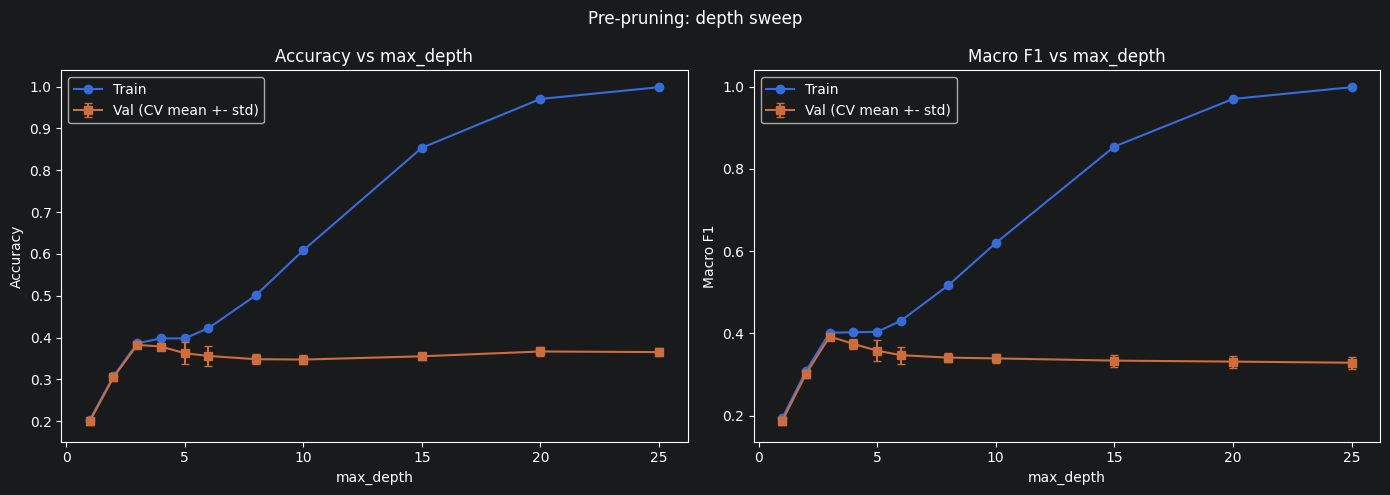

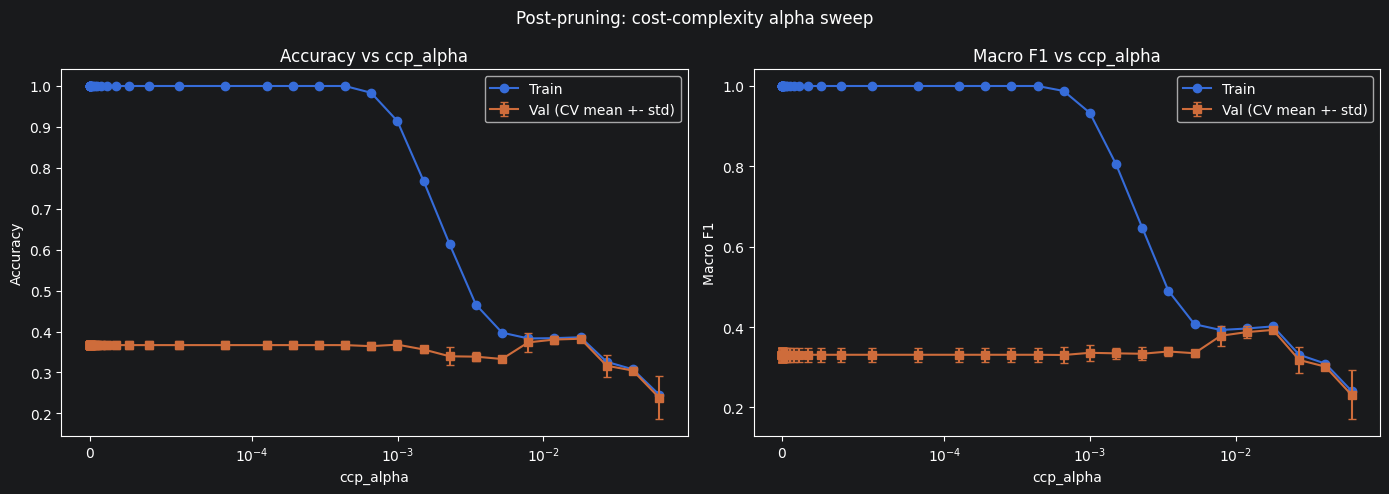

In [22]:
def plot_hyperparam_sweep(df, x_col, title, log_x=False):
    # remove 'unlimited' results (eg. in the max depth sweep)
    plot_df = df[df[x_col] != 'unlimited'].copy() if x_col == 'max_depth' else df
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, metric, label in zip(axes, ['acc', 'f1'], ['Accuracy', 'Macro F1']):
        ax.plot(plot_df[x_col], plot_df[f'train_{metric}'], 'o-', label='Train')
        # add error bar to visualise standard deviation
        ax.errorbar(plot_df[x_col], plot_df[f'val_{metric}'],
                    yerr=plot_df[f'val_{metric}_std'],
                    fmt='s-', label='Val (CV mean +- std)', capsize=3)
        ax.set_xlabel(x_col); ax.set_ylabel(label)
        ax.set_title(f'{label} vs {x_col}'); ax.legend()
        if log_x: ax.set_xscale('symlog', linthresh=1e-4)

    plt.suptitle(title); plt.tight_layout(); plt.show()

plot_hyperparam_sweep(depth_df, 'max_depth', 'Pre-pruning: depth sweep')
plot_hyperparam_sweep(alpha_df, 'ccp_alpha', 'Post-pruning: cost-complexity alpha sweep', log_x=True)

Best alpha: 0.00399, Best max depth: 3
Best CV macro F1: 0.39298


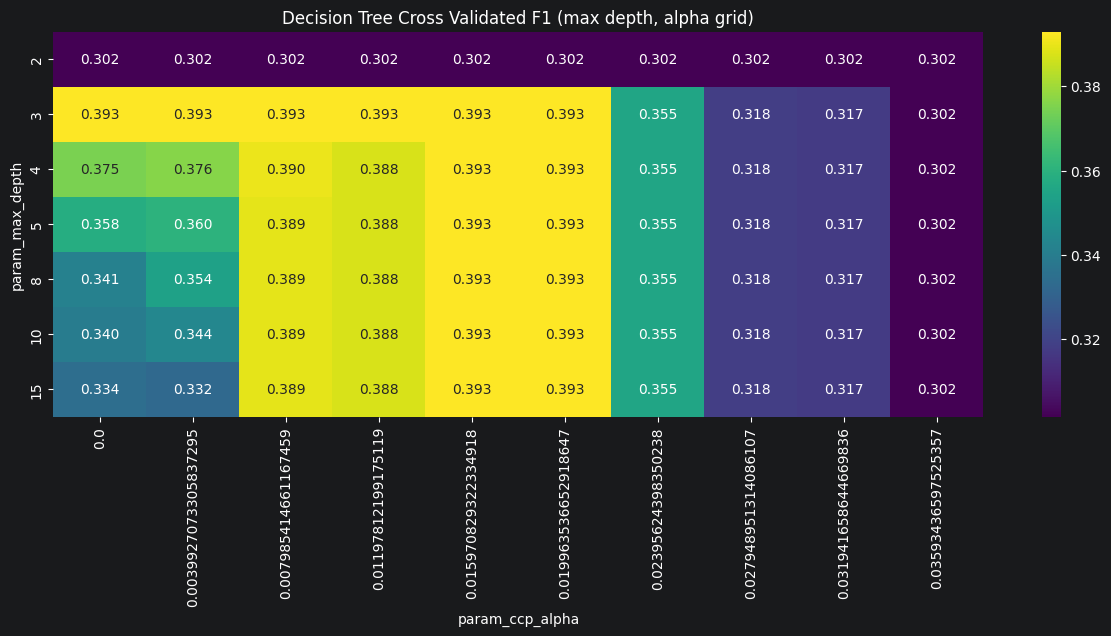

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':  [None, 2, 3, 4, 5, 8, 10, 15],
    # 'max_depth':  [None, 10, 15, 20, 30, 40],
    # 10 linear-spaced values from 0 to 2 * the best alpha score
    'ccp_alpha':  np.linspace(0, best_alpha * 2, 10)
}

grid = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', class_weight='balanced', random_state=0),
    param_grid, cv=skf, scoring='f1_macro',
    return_train_score=True, n_jobs=-1,
)
grid.fit(train_x_enc, train_y)

print(f'Best alpha: {grid.best_params_['ccp_alpha']:.5f}, Best max depth: {grid.best_params_["max_depth"]}')
print(f'Best CV macro F1: {grid.best_score_:.5f}')

# Heatmap of val F1 based on max depth and alpha values
grid_df = pd.DataFrame(grid.cv_results_)
pivot = grid_df.pivot_table(index='param_max_depth', columns='param_ccp_alpha', values='mean_test_score')
fig, ax = plt.subplots(figsize=(15, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax)
ax.set_title('Decision Tree Cross Validated F1 (max depth, alpha grid)')
plt.show()

## 4.4. Final Decision Tree and Results

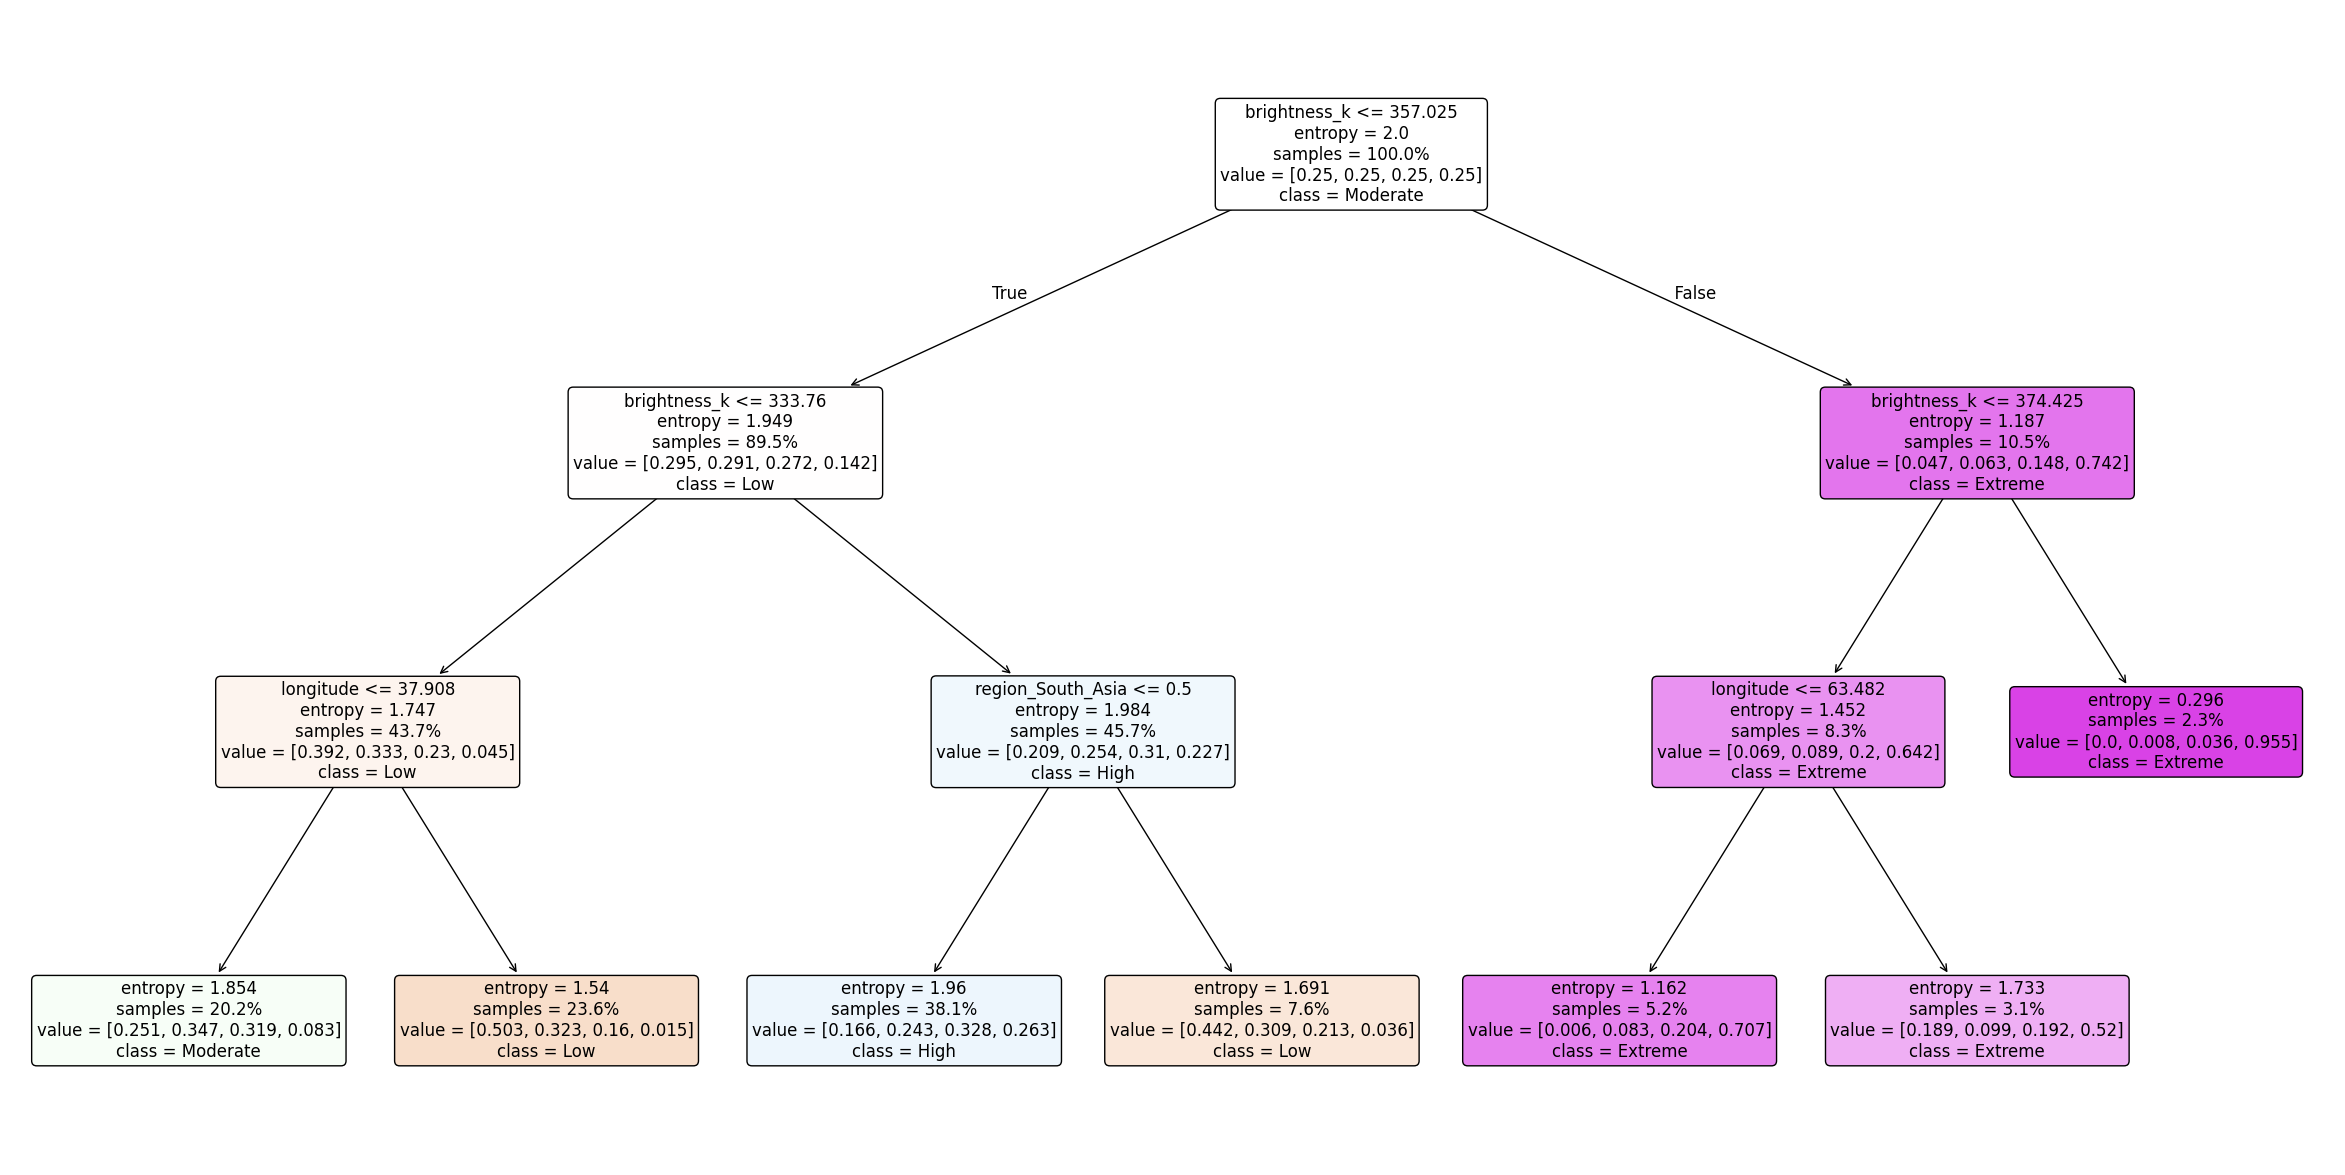

In [24]:
# Refit best model on all training data
final_tree = grid.best_estimator_

# Decision Tree visualisation
with plt.style.context('default'):
    fig, ax = plt.subplots(figsize=(30, 15), facecolor='white')
    plot_tree(
        final_tree, max_depth=3,
        # final_tree, max_depth=None,    # For determining feature importance. max_depth = none can also produce a ~0.393 F1 result
        feature_names=feature_names,
        class_names=['Low', 'Moderate', 'High', 'Extreme'],
        filled=True, rounded=True, proportion=True, fontsize=12, ax=ax,
    )
    plt.show()

**Notes**
- LEVEL 1: Brightness <= 357. False branch leads to a node with 10.5% of data of which ~75% of the data is in the extreme class. Thus, this one split obtains a majority of total extreme entries in the dataset.
- LEVEL 2 (L): Brightness <= 333. True branch is ~95% non-extreme. Seemingly, <333 kelvin is the cutoff for determining non-extreme instances.
- Level 2 (R): Brightness < 375. False branch is ~96% extreme. So this seems to be the cutoff on the opposite end.
- Further levels prune mainly based on location. <38 longitude splits low-moderate instances from moderate/high instances, and being in South Asia (FALSE on region_south_asia <= 0.5) almost guarantees a non-extreme intensity.

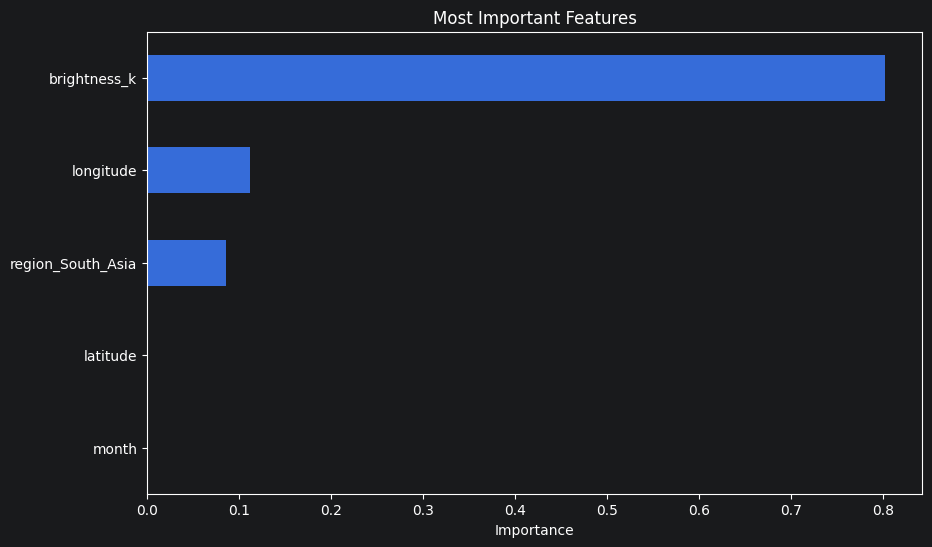

In [25]:
# Feature importance
importance = pd.Series(final_tree.feature_importances_, index=feature_names)
important_features = importance.sort_values(ascending=False).head(5)

fig, ax = plt.subplots(figsize=(10, 6))
important_features.plot(kind='barh', ax=ax)
ax.set_xlabel('Importance')
ax.set_title('Most Important Features')
ax.invert_yaxis()
plt.show()

**Notes**
- Looking at the most important features, brightness is clearly the biggest indicator
- Locational data follows, but at a much lower level of importance
- With such a low alpha, the tree is pruned extremely aggressively, so only the most important factors end up playing a part in classification. Though there isn't too much that we can extrapolate from this data, it is very clear that brightness plays a key role in determining fire intensity

              precision    recall  f1-score   support

         Low       0.25      0.47      0.33       140
    Moderate       0.51      0.25      0.33       384
        High       0.38      0.46      0.42       268
     Extreme       0.42      0.50      0.46        76

    accuracy                           0.37       868
   macro avg       0.39      0.42      0.38       868
weighted avg       0.42      0.37      0.37       868



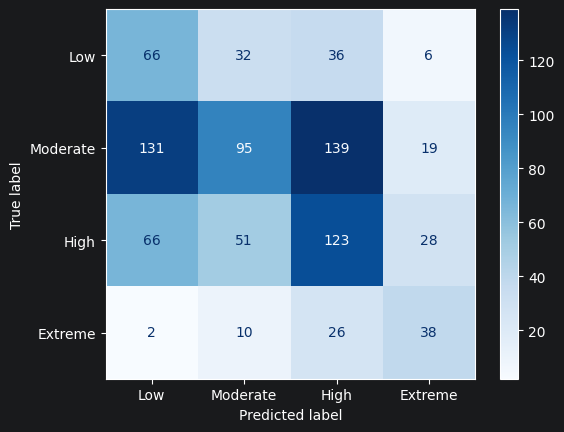

In [26]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Classification Report
test_pred = final_tree.predict(test_x_enc)

print(classification_report(test_y, test_pred, target_names=['Low', 'Moderate', 'High', 'Extreme']))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    final_tree, test_x_enc, test_y,
    display_labels=['Low', 'Moderate', 'High', 'Extreme'],
    cmap=plt.cm.Blues
)
plt.show()

**Notes**
- Accuracy is lower (.37) than just predicting the most common (moderate at ~44%), but macro f1 is higher (0.38 vs ~0.15)
- Low: Predicts often incorrectly (.25 precision)
- Moderate: Majority class, but has a very low precision, resulting from balanced class weight
- High: more or less average
- Extreme: relatively successful overall, especially for the minority class. Positive result of balanced class weight

In [27]:
# Final Decision Tree Results:
dt_test_acc = (test_pred == test_y).mean()
dt_test_f1 = f1_score(test_y, test_pred, average='macro')
print(f"Decision Tree test accuracy: {dt_test_acc:.3f}")
print(f"Decision Tree test macro F1: {dt_test_f1:.3f}")

Decision Tree test accuracy: 0.371
Decision Tree test macro F1: 0.382


# 5. Support Vector Machines

In [28]:
from sklearn.svm import SVC

clf = SVC(kernel='linear', C=1.0)
clf.fit(train_x_sc, train_y)

baseline_scores_svm = cv_scores(clf, train_x_sc, train_y, skf)
print(f"Train acc: {baseline_scores_svm['train_acc']:.3f}")
print(f"Val acc: {baseline_scores_svm['val_acc']:.3f} (std. deviation: {baseline_scores_svm['val_acc_std']:.3f})")
print()
print(f"Train F1:  {baseline_scores_svm['train_f1']:.3f}")
print(f"Val F1:  {baseline_scores_svm['val_f1']:.3f} (std. deviation: {baseline_scores_svm['val_f1_std']:.3f})")

Train acc: 0.495
Val acc: 0.453 (std. deviation: 0.015)

Train F1:  0.371
Val F1:  0.330 (std. deviation: 0.020)


**Notes**
- Baseline SVM has a lower F1 (.330) than the F1 of the optimised decision tree (.393)

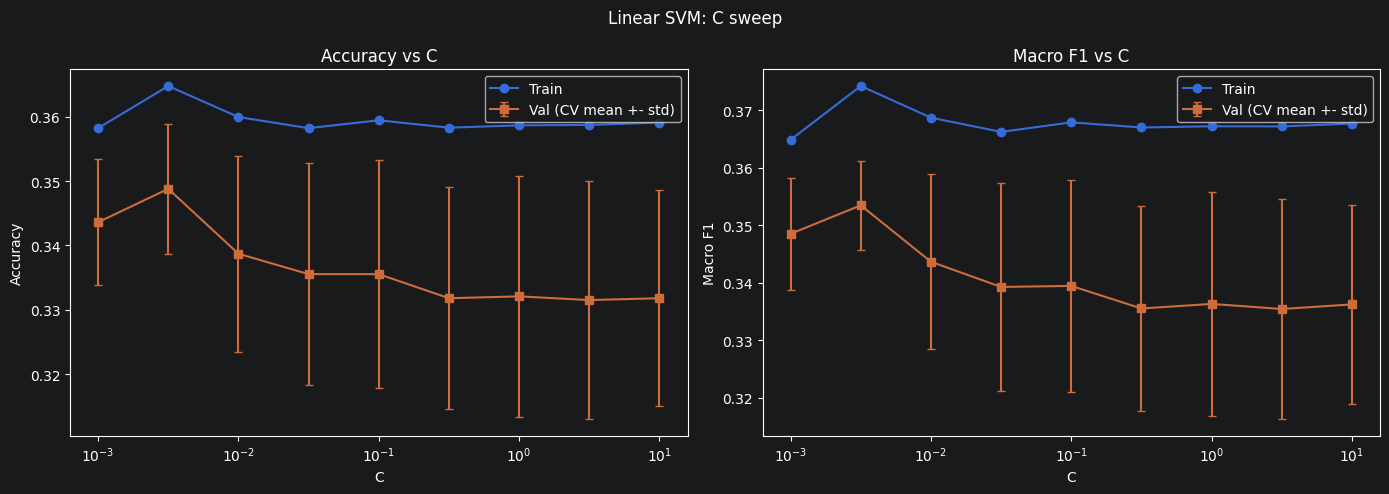

In [29]:
# Linear kernel C sweep
C_values = np.logspace(-3, 1, 9)  # 0.001 to 10, log-spaced

linear_results = []
for C in C_values:
    clf = SVC(kernel='linear', C=C, class_weight='balanced', random_state=0)
    row = {'C': C}
    row.update(cv_scores(clf, train_x_sc, train_y, skf))
    linear_results.append(row)

linear_df = pd.DataFrame(linear_results)
plot_hyperparam_sweep(linear_df, 'C', 'Linear SVM: C sweep', log_x=True)

**Notes**
- Initial sweep was between 0.001 and 1000
- Reduced to 0.001 - 10, which is the majority of the relevant range

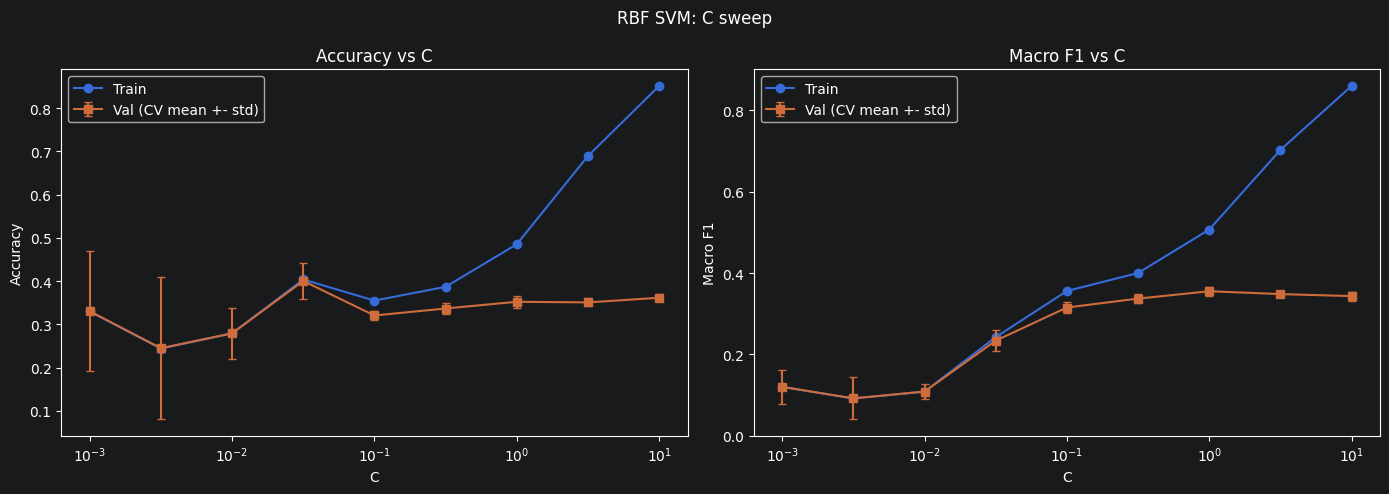

In [30]:
# RBF kernel C sweep
rbf_results = []
for C in C_values:
    clf = SVC(kernel='rbf', C=C, class_weight='balanced', gamma='scale', random_state=0)
    row = {'C': C}
    row.update(cv_scores(clf, train_x_sc, train_y, skf))
    rbf_results.append(row)

rbf_df = pd.DataFrame(rbf_results)
plot_hyperparam_sweep(rbf_df, 'C', 'RBF SVM: C sweep', log_x=True)

In [31]:
# GAMMA TEST - Not necessary

# gamma_values = np.logspace(-4, 1, 11)
# # C set at the optimal value from rbf sweep
# best_rbf_C = rbf_df.loc[rbf_df['val_f1'].idxmax(), 'C']
#
# gamma_results = []
# for g in gamma_values:
#     clf = SVC(kernel='rbf', C=best_rbf_C, class_weight='balanced', gamma=g, random_state=0)
#     row = {'gamma': g}
#     row.update(cv_scores(clf, train_x_sc, train_y, skf))
#     gamma_results.append(row)
#
# gamma_df = pd.DataFrame(gamma_results)
# plot_hyperparam_sweep(gamma_df, 'gamma', 'RBF SVM: gamma sweep', log_x=True)

In [32]:
linear_best = linear_df.loc[linear_df['val_f1'].idxmax()]
rbf_best    = rbf_df.loc[rbf_df['val_f1'].idxmax()]
# gamma_best = gamma_df.loc[gamma_df['val_f1'].idxmax()]

print("Linear kernel C — best:")
print(f"  C = {linear_best['C']:.4g}")
print(f"  Train F1: {linear_best['train_f1']:.3f}")
print(f"  Val F1:   {linear_best['val_f1']:.3f} (std {linear_best['val_f1_std']:.3f})")
print(f"  Val acc:  {linear_best['val_acc']:.3f}")

print("\nRBF kernel C — best:")
print(f"  C = {rbf_best['C']:.4g}")
print(f"  Train F1: {rbf_best['train_f1']:.3f}")
print(f"  Val F1:   {rbf_best['val_f1']:.3f} (std {rbf_best['val_f1_std']:.3f})")
print(f"  Val acc:  {rbf_best['val_acc']:.3f}")

# GAMMA TEST - Not necessary
# print("\nRBF kernel gamma — best:")
# print(f"  Gamma = {gamma_best['gamma']:.4g}")
# print(f"  Train F1: {gamma_best['train_f1']:.3f}")
# print(f"  Val F1:   {gamma_best['val_f1']:.3f} (std {gamma_best['val_f1_std']:.3f})")
# print(f"  Val acc:  {gamma_best['val_acc']:.3f}")

Linear kernel C — best:
  C = 0.003162
  Train F1: 0.374
  Val F1:   0.353 (std 0.008)
  Val acc:  0.349

RBF kernel C — best:
  C = 1
  Train F1: 0.507
  Val F1:   0.355 (std 0.011)
  Val acc:  0.352


              precision    recall  f1-score   support

         Low       0.26      0.58      0.36       140
    Moderate       0.45      0.16      0.24       384
        High       0.35      0.37      0.36       268
     Extreme       0.27      0.49      0.35        76

    accuracy                           0.32       868
   macro avg       0.33      0.40      0.33       868
weighted avg       0.37      0.32      0.31       868



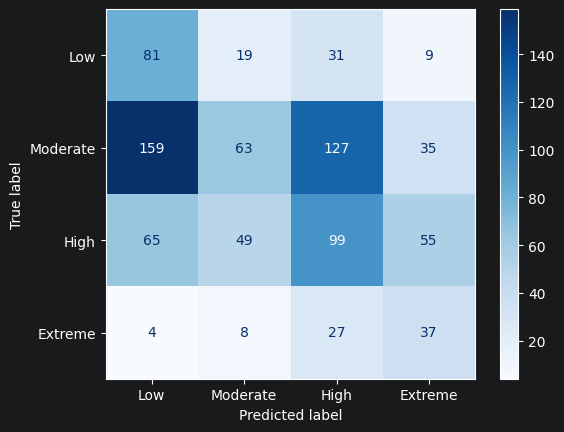

In [33]:
# Best SVM
final_svm = SVC(kernel='rbf', C=rbf_best['C'], gamma='scale', class_weight='balanced', random_state=0)
final_svm.fit(train_x_sc, train_y)

svm_test_pred = final_svm.predict(test_x_sc)
print(classification_report(test_y, svm_test_pred, target_names=['Low','Moderate','High','Extreme']))
ConfusionMatrixDisplay.from_estimator(
    final_svm, test_x_sc, test_y,
    display_labels=['Low','Moderate','High','Extreme'],
    cmap=plt.cm.Blues)
plt.show()

**Notes**
- Final model uses balanced class_weight to remain consistent with the results of the Decision Tree
- More balanced than the decision tree results. Better at identifying the majority class
- Overall, slightly worse at predicting than decision trees

In [34]:
# Final SVM Results:
svm_test_acc = (svm_test_pred == test_y).mean()
svm_test_f1 = f1_score(test_y, svm_test_pred, average='macro')
print(f"Support Vector Machine test accuracy: {svm_test_acc:.3f}")
print(f"Support Vector Machine test macro F1: {svm_test_f1:.3f}")

Support Vector Machine test accuracy: 0.323
Support Vector Machine test macro F1: 0.327


# 6. Neural Networks

In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight

# SETUP

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# train_x_sc_nn, val_x_sc_nn, test_x_sc_nn
print(f'Train size: {train_x_sc_nn.shape[0]}')
print(f'Validation size: {val_x_sc_nn.shape[0]}')
print(f'Test size: {test_x_sc_nn.shape[0]}')

Using device: cpu
Train size: 2604
Validation size: 868
Test size: 868


In [36]:
#
class WildfireNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_classes):
        super(WildfireNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_classes)

    def forward(self, x):
        x = self.fc1(x)
#         x = torch.sigmoid(x)
        x = torch.relu(x)
        x = self.fc2(x)
        return x

def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= len(train_loader)
    train_acc = train_correct / train_total
    return train_loss, train_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)

            outputs = model(features)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = val_correct / val_total
    return val_loss, val_acc

# Obtains all predictions and actual vales and computes accuracy and macro f1 from a loader. Used at the end of each fold
def evaluate_loader(model, loader, device):
    model.eval()
    all_y, all_p = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            p = model(x).argmax(1).cpu().numpy()
            all_y.extend(y.numpy())
            all_p.extend(p)
    acc = (np.array(all_p) == np.array(all_y)).mean()
    f1 = f1_score(all_y, all_p, average='macro')
    return acc, f1


In [37]:
# Hyperparameters
INPUT_DIM = train_x_sc.shape[1]
HIDDEN_DIM = 64
OUTPUT_CLASSES = 4
batch_size = 32
epochs = 120
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.15, 0.2, 0.25]

# addresses class imbalance in a multi-class classification problem
class_weights_np = compute_class_weight('balanced', classes=np.array([0, 1, 2, 3]), y=train_y.values)
class_weights = torch.FloatTensor(class_weights_np).to(device)
print(f"Class weights: {class_weights_np.round(3)}")

# convert train_y to raw values (currently a series). Change train_x as well for  cleaner formatting
train_x_np = train_x_sc
train_y_np = train_y.values

histories = {}

for lr in learning_rates:
    fold_tr_loss = []
    fold_va_loss = []
    fold_tr_acc = []
    fold_va_acc = []
    fold_tr_f1 = []
    fold_final_f1 = []

    for fold, (tr_idx, va_idx) in enumerate(skf.split(train_x_np, train_y_np)):
        # Slice this fold
        X_tr, X_va = train_x_np[tr_idx], train_x_np[va_idx]
        y_tr, y_va = train_y_np[tr_idx], train_y_np[va_idx]

        # Tensors + DataLoaders
        tr_loader = DataLoader(
            TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long)),
            batch_size=batch_size, shuffle=True)
        va_loader = DataLoader(
            TensorDataset(torch.tensor(X_va, dtype=torch.float32),torch.tensor(y_va, dtype=torch.long)),
            batch_size=batch_size, shuffle=False)

        # new model and optimizer for each fold to avoid data leakage
        torch.manual_seed(0)
        model = WildfireNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_CLASSES).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        optimizer = optim.SGD(model.parameters(), lr=lr)

        tr_losses = []
        va_losses = []
        tr_accs = []
        va_accs = []
        for epoch in range(epochs):
            tl, ta = train_epoch(model, tr_loader, criterion, optimizer, device)
            vl, va = validate_epoch(model, va_loader, criterion, device)
            tr_losses.append(tl); va_losses.append(vl)
            tr_accs.append(ta);   va_accs.append(va)

        # Fold-wide macro F1
        _, fold_f1 = evaluate_loader(model, va_loader, device)
        # Training macro F1 for model evaluation
        _, tr_f1 = evaluate_loader(model, tr_loader, device)

        fold_tr_loss.append(tr_losses); fold_va_loss.append(va_losses)
        fold_tr_acc.append(tr_accs);    fold_va_acc.append(va_accs)
        fold_tr_f1.append(tr_f1)
        fold_final_f1.append(fold_f1)

    histories[lr] = {
        'train_loss': np.array(fold_tr_loss),
        'val_loss': np.array(fold_va_loss),
        'train_acc': np.array(fold_tr_acc),
        'val_acc': np.array(fold_va_acc),
        'train_f1': np.array(fold_tr_f1),
        'final_f1': np.array(fold_final_f1)
    }
    #
    # va_acc_final = histories[lr]['val_acc'][:, -1]
    # va_f1_final  = histories[lr]['final_f1']
    # print(f"lr = {lr:<8} | val acc = {va_acc_final.mean():.3f} +- {va_acc_final.std():.3f} | val F1 = {va_f1_final.mean():.3f} +- {va_f1_final.std():.3f}")

Class weights: [1.556 0.565 0.81  2.846]
lr = 0.0001   | val acc = 0.301 +- 0.009 | val F1 = 0.293 +- 0.010
lr = 0.001    | val acc = 0.335 +- 0.016 | val F1 = 0.344 +- 0.015
lr = 0.01     | val acc = 0.364 +- 0.008 | val F1 = 0.361 +- 0.008
lr = 0.1      | val acc = 0.372 +- 0.021 | val F1 = 0.335 +- 0.011
lr = 0.15     | val acc = 0.376 +- 0.016 | val F1 = 0.347 +- 0.014
lr = 0.2      | val acc = 0.375 +- 0.010 | val F1 = 0.340 +- 0.008
lr = 0.25     | val acc = 0.369 +- 0.017 | val F1 = 0.335 +- 0.021


In [38]:
# Create a dataframe, mirroring those created for DT and SVM
nn_summary = pd.DataFrame([
    {
        'lr': lr,
        'train_f1': hist['train_f1'].mean(),
        'val_f1': hist['final_f1'].mean(),
        'val_f1_std': hist['final_f1'].std(),
        'gap': hist['train_f1'].mean() - hist['final_f1'].mean(),
    }
    for lr, hist in histories.items()
])
print(nn_summary.to_string(index=False))

    lr  train_f1   val_f1  val_f1_std      gap
0.0001  0.304461 0.293213    0.009931 0.011248
0.0010  0.387353 0.343914    0.014533 0.043439
0.0100  0.625526 0.361451    0.007886 0.264076
0.1000  0.900608 0.334763    0.010790 0.565844
0.1500  0.890540 0.347129    0.014498 0.543411
0.2000  0.892295 0.339737    0.007639 0.552558
0.2500  0.879803 0.334529    0.020600 0.545275


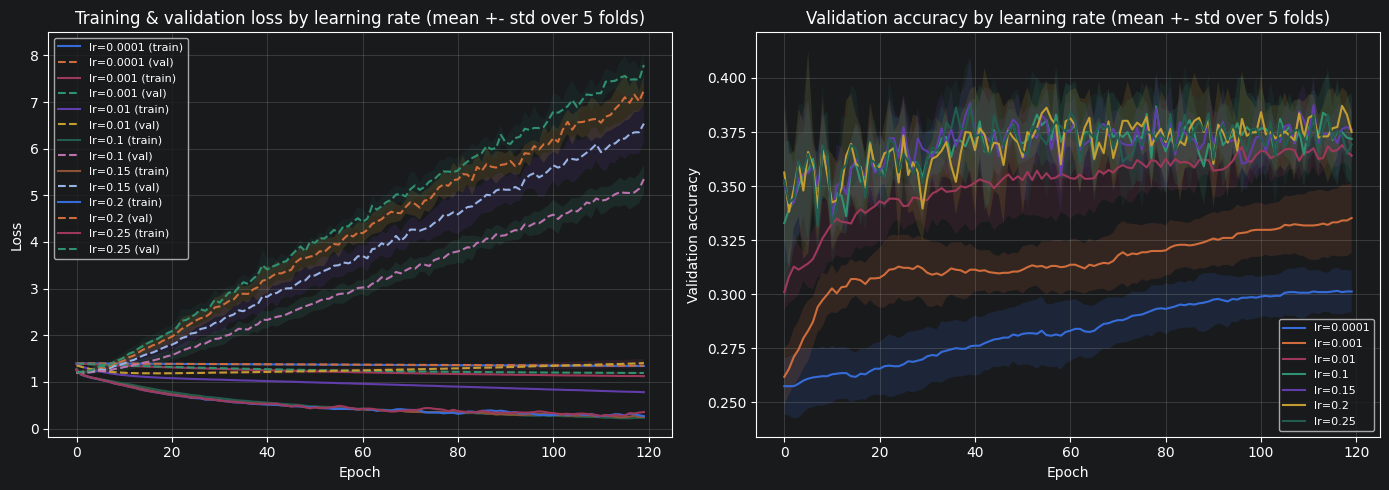

In [39]:
# fig, axes = plt.subplots(1, 2, figsize=(40, 15))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for lr, hist in histories.items():
    tr_mean = hist['train_loss'].mean(axis=0)
    va_mean = hist['val_loss'].mean(axis=0)
    va_std  = hist['val_loss'].std(axis=0)
    va_acc_mean = hist['val_acc'].mean(axis=0)
    va_acc_std  = hist['val_acc'].std(axis=0)

    epochs_x = np.arange(len(tr_mean))
    # Solid line for train
    axes[0].plot(epochs_x, tr_mean, linestyle='-', label=f'lr={lr} (train)')
    # dashed line for validation
    axes[0].plot(epochs_x, va_mean, linestyle='--', label=f'lr={lr} (val)')
    # show mean +- standard deviation (loss)
    axes[0].fill_between(epochs_x, va_mean - va_std, va_mean + va_std, alpha=0.15)

    axes[1].plot(epochs_x, va_acc_mean, label=f'lr={lr}')
    # show mean +- standard deviation (accuracy)
    axes[1].fill_between(epochs_x, va_acc_mean - va_acc_std, va_acc_mean + va_acc_std, alpha=0.15)

axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & validation loss by learning rate (mean +- std over 5 folds)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Validation accuracy')
axes[1].set_title('Validation accuracy by learning rate (mean +- std over 5 folds)')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

         Low       0.27      0.44      0.34       140
    Moderate       0.48      0.33      0.39       384
        High       0.36      0.33      0.34       268
     Extreme       0.31      0.50      0.38        76

    accuracy                           0.36       868
   macro avg       0.35      0.40      0.36       868
weighted avg       0.39      0.36      0.37       868



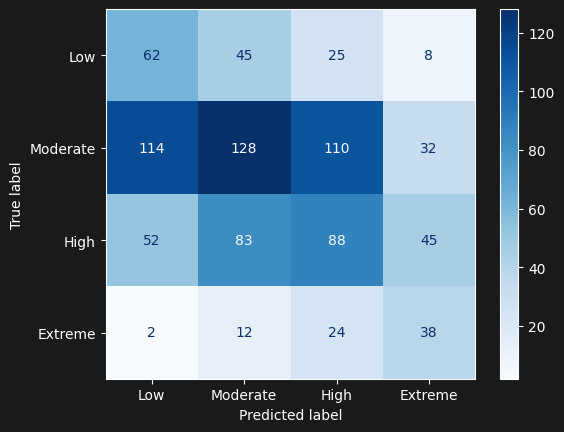

NN test accuracy: 0.364
NN test macro F1: 0.363


In [40]:
# lr set to the most stable value that produced the max F1
best_lr = 0.01

# Retrain on the training set with the best learnin grate
full_loader = DataLoader(
    TensorDataset(torch.tensor(train_x_sc, dtype=torch.float32),
                  torch.tensor(train_y.values, dtype=torch.long)),
    batch_size=batch_size, shuffle=True)

torch.manual_seed(0)
final_nn = WildfireNN(INPUT_DIM, HIDDEN_DIM, OUTPUT_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.SGD(final_nn.parameters(), lr=best_lr)
for epoch in range(epochs):
    train_epoch(final_nn, full_loader, criterion, optimizer, device)

# Build test loader and evaluate
test_loader = DataLoader(
    TensorDataset(torch.tensor(test_x_sc, dtype=torch.float32), torch.tensor(test_y.values, dtype=torch.long)),
    batch_size=batch_size, shuffle=False)

final_nn.eval()
all_pred = []
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        all_pred.extend(final_nn(x).argmax(1).cpu().numpy())

nn_test_pred = np.array(all_pred)
print(classification_report(test_y, nn_test_pred,
                            target_names=['Low','Moderate','High','Extreme']))

cm = confusion_matrix(test_y, nn_test_pred)
ConfusionMatrixDisplay(cm, display_labels=['Low','Moderate','High','Extreme']
                      ).plot(cmap=plt.cm.Blues)
plt.show()

nn_test_acc = (nn_test_pred == test_y.values).mean()
nn_test_f1  = f1_score(test_y, nn_test_pred, average='macro')
print(f"NN test accuracy: {nn_test_acc:.3f}")
print(f"NN test macro F1: {nn_test_f1:.3f}")

# 7. Final Evaluation

In [41]:
final_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'SVM (RBF, balanced)', 'Neural Network'],
    'Test Accuracy': [dt_test_acc, svm_test_acc, nn_test_acc],
    'Test Macro F1': [dt_test_f1,  svm_test_f1,  nn_test_f1],
})
print(final_comparison.to_string(index=False))

              Model  Test Accuracy  Test Macro F1
      Decision Tree       0.370968       0.382181
SVM (RBF, balanced)       0.322581       0.327368
     Neural Network       0.364055       0.362858


**Notes**
- Clear winner based on results: Decision Tree
- Simpler model seems to work better with the less feature-rich dataset. Only one real important feature

# 8. Generate Predictions

In [46]:
# Predict on the unseen test features using the chosen final model
unk_pred = final_tree.predict(unk_x_enc)

# Decode ordinal values back to category names
intensity_labels = {0: 'Low', 1: 'Moderate', 2: 'High', 3: 'Extreme'}
unk_pred_labels = pd.Series(unk_pred).map(intensity_labels)

# Save as CSV
submission = pd.DataFrame({'fire_intensity': unk_pred_labels})
submission.to_csv('s3787701_predictions.csv', header=True, index=False)
print('saved')
print(submission['fire_intensity'].value_counts())

saved
fire_intensity
High        366
Low         345
Moderate    248
Extreme     126
Name: count, dtype: int64
